# Pipeline: getting news articles per market

## Keyword generation

In [ ]:
import os
import json
from dotenv import load_dotenv
from groq import Groq

load_dotenv()

client = Groq(api_key=os.getenv("GROQ_API_KEY_1"))

MODEL = "llama-3.3-70b-versatile" # knowledge cutoff in December 2023 (?)

NUM_KEYWORDS = 3
MAX_WORDS = 5

def call_llm(prompt: str) -> str:
    resp = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "user", "content": prompt}
        ],
        temperature=0.2,
    )
    return resp.choices[0].message.content


def extract_queries(text: str):
    for line in text.splitlines():
        if "Search Queries" in line:
            part = line.split(":", 1)[-1]
            queries = [q.strip() for q in part.split(";") if q.strip()]
            return queries
    return []


def build_prompt_1(question, resolution_criteria):
    return f"""I will provide you with a forecasting question and the resolution criteria for the question.
Question: {question}
Resolution criteria: {resolution_criteria}
Task:
- Generate brief search queries (up to {MAX_WORDS} words each) to gather information on Google that could influence the forecast.
You must generate this exact amount of queries: {NUM_KEYWORDS}
Your response should take the following structure: Thoughts: {{ Insert your thinking here. }}
Search Queries: {{ Insert the queries here. Use semicolons to separate the queries. }}"""


def build_prompt_2(question, resolution_criteria):
    return f"""I will provide you with a forecasting question and the resolution criteria for the question. I will
then ask you to generate short search queries (up to {MAX_WORDS} words each) that I’ll use to find
articles on Google News to help answer the question.
Question: {question}
Resolution criteria: {resolution_criteria}
You must generate this exact amount of queries: {NUM_KEYWORDS}
Start off by writing down sub-questions. Then use your sub-questions to help steer the search queries
you produce.
Your response should take the following structure: Thoughts: {{ Insert your thinking here. }}
Search Queries: {{ Insert the queries here. Use semicolons to separate the queries. }}"""


def process_item(item):
    q = item["question"]
    r = item["resolution_criteria"]

    out1 = call_llm(build_prompt_1(q, r))
    out2 = call_llm(build_prompt_2(q, r))

    queries = extract_queries(out1) + extract_queries(out2)

    # deduplicate (case-insensitive)
    seen = set()
    final_queries = []
    for x in queries:
        key = x.lower()
        if key not in seen:
            seen.add(key)
            final_queries.append(x)

    item["search_queries"] = final_queries
    return item

input_path = "data/sample_markets.json"
output_path = "data/sample_markets_queries.json"

os.makedirs("data", exist_ok=True)

with open(input_path, "r", encoding="utf-8") as f:
    data = json.load(f)

enriched = []
for i, item in enumerate(data, start=1):
    print(f"Processing item {i}/{len(data)}: {item.get('question', '')[:60]}...")
    enriched.append(process_item(item))

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(enriched, f, indent=2, ensure_ascii=False)

Processing item 1/10: Will Aljamain Sterling fight Alexander Volkanovski next?...
Processing item 2/10: Will Bilibili Gaming win the LPL 2026 season?...
Processing item 3/10: Will Giorgos Giakoumakis record the most cards in 2025-26 UE...
Processing item 4/10: Will the official USD to ARS exchange rate be between 1700.0...
Processing item 5/10: Abstract FDV above $800M one day after launch?...
Processing item 6/10: Will Amir Albazi be the UFC Flyweight Champion on December 3...
Processing item 7/10: Will Antonio Villaraigosa win the California Governor Electi...
Processing item 8/10: Will Nicolás Maduro be the leader of Venezuela end of 2026?...
Processing item 9/10: Will Seth Jarvis win the 2025–2026 NHL Maurice 'Rocket' Rich...
Processing item 10/10: Predict.fun FDV above $1.5B one day after launch?...


## 1) Get news articles: Google News + GNews

In [35]:
import json
import os
import requests
import time
from dotenv import load_dotenv

load_dotenv(override=True)

API_KEY = os.getenv("GNEWS_API_KEY_2")
INPUT_PATH = "data/sample_markets_queries.json"
OUTPUT_PATH = "data/01_google_news/sample_markets_articles.json"
BASE_URL = "https://gnews.io/api/v4/search"


def to_gnews_format(dt):
    return dt.split(".")[0] + ".000Z"


def clean_query(q):
    q = q.strip()
    # if special characters like "." exist → wrap in quotes
    if any(c in q for c in [".", "-", "!", "?"]):
        return f'"{q}"'
    return q


def fetch_articles(query, start_date, end_date):
    query = clean_query(query)
    print(f"\nQuery: {query}")

    params = {
        "q": query,
        "lang": "en",
        "max": 10,
        "sortby": "publishedAt",
        "from": start_date,
        "to": end_date,
        "apikey": API_KEY
    }

    r = requests.get(BASE_URL, params=params)
    data = r.json()

    if r.status_code != 200:
        print("  API ERROR:", data)
        return []

    articles = data.get("articles", [])
    print(f"  Found {len(articles)} articles")

    results = []

    for i, a in enumerate(articles, start=1):
        print(f"    Article {i}/{len(articles)}")

        results.append({
            "query": query,
            "title": a.get("title"),
            "source": a.get("source", {}).get("name"),
            "published_date": a.get("publishedAt"),
            "url": a.get("url"),
            "full_text": a.get("content")
        })

    return results


with open(INPUT_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)


enriched = []

print(f"Total markets: {len(data)}")

for mi, market in enumerate(data, start=1):
    print(f"\n\n===== Market {mi}/{len(data)} =====")
    print(market.get("question"))

    start_date = to_gnews_format(market.get("start_date"))
    end_date = to_gnews_format(market.get("today_date"))

    all_articles = []
    seen_urls = set()

    queries = market.get("search_queries", [])
    print(f"Total queries: {len(queries)}")

    for qi, q in enumerate(queries, start=1):
        print(f"\n=== Query {qi}/{len(queries)} ===")

        batch = fetch_articles(q, start_date, end_date)

        for a in batch:
            url = a.get("url")
            if url and url not in seen_urls:
                seen_urls.add(url)
                all_articles.append(a)

        time.sleep(1.05)

    print("\n--- Market Summary ---")
    print(f"Total unique articles: {len(all_articles)}")

    market["articles"] = all_articles
    enriched.append(market)

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(enriched, f, indent=2, ensure_ascii=False)

print("\nSaved:", OUTPUT_PATH)

Total markets: 10


===== Market 1/10 =====
Will Aljamain Sterling fight Alexander Volkanovski next?
Total queries: 6

=== Query 1/6 ===

Query: Volkanovski next fight
  Found 3 articles
    Article 1/3
    Article 2/3
    Article 3/3

=== Query 2/6 ===

Query: UFC upcoming bouts
  Found 0 articles

=== Query 3/6 ===

Query: Alexander Volkanovski schedule
  Found 0 articles

=== Query 4/6 ===

Query: Alexander Volkanovski next fight
  Found 3 articles
    Article 1/3
    Article 2/3
    Article 3/3

=== Query 5/6 ===

Query: Volkanovski upcoming UFC bout
  Found 0 articles

=== Query 6/6 ===

Query: UFC announces Volkanovski opponent
  Found 0 articles

--- Market Summary ---
Total unique articles: 3


===== Market 2/10 =====
Will Bilibili Gaming win the LPL 2026 season?
Total queries: 6

=== Query 1/6 ===

Query: LPL 2026 schedule
  Found 1 articles
    Article 1/1

=== Query 2/6 ===

Query: Bilibili Gaming roster
  Found 0 articles

=== Query 3/6 ===

Query: LPL season updates
  Foun

In [36]:
import json
import time
import requests
from newspaper import Article
from readability import Document
from bs4 import BeautifulSoup

INPUT_PATH = "data/01_google_news/sample_markets_articles.json"
OUTPUT_PATH = "data/01_google_news/sample_markets_articles_scraped.json"

HEADERS = {
    "User-Agent": "Mozilla/5.0 (compatible; research-bot/1.0)"
}


def extract_newspaper(url):
    try:
        a = Article(url)
        a.download()
        a.parse()
        if a.text and len(a.text) > 200:
            return a.text
    except Exception:
        pass
    return None


def extract_readability(url):
    try:
        r = requests.get(url, headers=HEADERS, timeout=10)

        if not r.text or len(r.text) < 200:
            print(f"[READABILITY FAIL] Empty HTML: {url}")
            return None

        doc = Document(r.text)
        html = doc.summary()

        if not html or len(html) < 200:
            print(f"[READABILITY FAIL] No content: {url}")
            return None

        soup = BeautifulSoup(html, "html.parser")
        text = soup.get_text("\n")

        return text if len(text) > 200 else None

    except Exception as e:
        print(f"[READABILITY ERROR] {url} -> {type(e).__name__}")
        return None


def extract_fallback(url):
    try:
        r = requests.get(url, headers=HEADERS, timeout=10)
        soup = BeautifulSoup(r.text, "html.parser")
        paragraphs = soup.find_all("p")
        text = "\n".join(p.get_text() for p in paragraphs)
        if len(text) > 200:
            return text
    except Exception:
        pass
    return None


def get_full_text(url):
    text = extract_newspaper(url)
    if text:
        return text

    text = extract_readability(url)
    if text:
        return text

    return extract_fallback(url)


# load file
with open(INPUT_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)


enriched = []

print(f"Total markets: {len(data)}")

for mi, market in enumerate(data, start=1):
    print(f"\n\n===== Market {mi}/{len(data)} =====")

    articles = market.get("articles", [])
    print(f"Scraping {len(articles)} articles...\n")

    missing = 0

    for i, a in enumerate(articles, start=1):
        url = a.get("url")

        print(f"[{i}/{len(articles)}] {url}")

        if not url:
            continue

        text = get_full_text(url)

        if not text:
            missing += 1

        a["full_text"] = text

        time.sleep(1.0)

    print("\n--- Market Summary ---")
    print(f"Total articles: {len(articles)}")

    if articles:
        print(f"Missing full text: {missing} ({missing/len(articles):.2%})")
    else:
        print(f"Missing full text: {missing} (0%)")

    enriched.append(market)


# save all markets
with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(enriched, f, indent=2, ensure_ascii=False)

print("\nSaved:", OUTPUT_PATH)

Total markets: 10


===== Market 1/10 =====
Scraping 3 articles...

[1/3] https://www.yardbarker.com/mma/articles/ufc_has_reportedly_decided_between_movsar_evloev_and_jean_silva_for_the_alexander_volkanovski_fight/s1_17651_43670371
[2/3] https://www.yardbarker.com/mma/articles/alexander_volkanovskis_team_strongly_rejects_a_jean_silva_title_shot_barking_like_a_little_dog/s1_17651_43653214
[3/3] https://www.yardbarker.com/mma/articles/movsar_evloevs_title_shot_in_doubt_after_ufc_legend_exposes_dana_whites_lack_of_commitment/s1_17730_43649797

--- Market Summary ---
Total articles: 3
Missing full text: 0 (0.00%)


===== Market 2/10 =====
Scraping 1 articles...

[1/1] https://cricketaddictor.com/cricket-news/lpl-2026-sri-lanka-cricket-reveals-dates-and-four-venues-for-upcoming-season-440467/

--- Market Summary ---
Total articles: 1
Missing full text: 0 (0.00%)


===== Market 3/10 =====
Scraping 0 articles...


--- Market Summary ---
Total articles: 0
Missing full text: 0 (0%)


===== Mark

## 2) Get news articles: NewsAPI.org

In [38]:
import json
import os
import time
import requests
from dotenv import load_dotenv

load_dotenv(override=True)

API_KEY = os.getenv("NEWSAPI_ORG_KEY")

INPUT_PATH = "data/sample_markets_queries.json"
OUTPUT_PATH = "data/02_newsapi_org/sample_markets_articles.json"

BASE_URL = "https://newsapi.org/v2/everything"


def to_newsapi_date(dt):
    return dt.split("T")[0]


def fetch_articles(query, start_date, end_date):
    query = query.strip()
    print(f"\nQuery: {query}")

    params = {
        "q": query,
        "language": "en",
        "pageSize": 10,
        "sortBy": "publishedAt",
        # "from": start_date,
        # "to": end_date,
        "apiKey": API_KEY,
    }

    r = requests.get(BASE_URL, params=params)
    data = r.json()

    if r.status_code != 200:
        print("  API ERROR:", data)
        return []

    articles = data.get("articles", [])
    print(f"  Found {len(articles)} articles")

    results = []

    for i, a in enumerate(articles, start=1):
        print(f"    Article {i}/{len(articles)}")

        results.append({
            "query": query,
            "title": a.get("title"),
            "source": a.get("source", {}).get("name"),
            "published_date": a.get("publishedAt"),
            "url": a.get("url"),
            "full_text": a.get("content")
        })

    return results


with open(INPUT_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)


enriched = []

print(f"Total markets: {len(data)}")

for mi, market in enumerate(data, start=1):
    print(f"\n\n===== Market {mi}/{len(data)} =====")
    print(market.get("question"))

    start_date = to_newsapi_date(market.get("start_date"))
    end_date = to_newsapi_date(market.get("today_date"))

    queries = market.get("search_queries", [])

    all_articles = []
    seen_urls = set()

    print(f"Total queries: {len(queries)}")

    for qi, q in enumerate(queries, start=1):
        print(f"\n=== Query {qi}/{len(queries)} ===")

        batch = fetch_articles(q, start_date, end_date)

        for a in batch:
            url = a.get("url")
            if url and url not in seen_urls:
                seen_urls.add(url)
                all_articles.append(a)

        time.sleep(1)  # respect rate limits

    print("\n--- Market Summary ---")
    print(f"Total unique articles: {len(all_articles)}")

    market["articles"] = all_articles
    enriched.append(market)


with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(enriched, f, indent=2, ensure_ascii=False)

print("\nSaved:", OUTPUT_PATH)

Total markets: 10


===== Market 1/10 =====
Will Aljamain Sterling fight Alexander Volkanovski next?
Total queries: 6

=== Query 1/6 ===

Query: Volkanovski next fight
  Found 10 articles
    Article 1/10
    Article 2/10
    Article 3/10
    Article 4/10
    Article 5/10
    Article 6/10
    Article 7/10
    Article 8/10
    Article 9/10
    Article 10/10

=== Query 2/6 ===

Query: UFC upcoming bouts
  Found 10 articles
    Article 1/10
    Article 2/10
    Article 3/10
    Article 4/10
    Article 5/10
    Article 6/10
    Article 7/10
    Article 8/10
    Article 9/10
    Article 10/10

=== Query 3/6 ===

Query: Alexander Volkanovski schedule
  Found 1 articles
    Article 1/1

=== Query 4/6 ===

Query: Alexander Volkanovski next fight
  Found 10 articles
    Article 1/10
    Article 2/10
    Article 3/10
    Article 4/10
    Article 5/10
    Article 6/10
    Article 7/10
    Article 8/10
    Article 9/10
    Article 10/10

=== Query 5/6 ===

Query: Volkanovski upcoming UFC bout
  F

In [39]:
import json
import time
import requests
from newspaper import Article
from readability import Document
from bs4 import BeautifulSoup

INPUT_PATH = "data/02_newsapi_org/sample_markets_articles.json"
OUTPUT_PATH = "data/02_newsapi_org/sample_markets_articles_scraped.json"

HEADERS = {
    "User-Agent": "Mozilla/5.0 (compatible; research-bot/1.0)"
}


def extract_newspaper(url):
    try:
        a = Article(url)
        a.download()
        a.parse()
        if a.text and len(a.text) > 200:
            return a.text
    except Exception:
        pass
    return None


def extract_readability(url):
    try:
        r = requests.get(url, headers=HEADERS, timeout=10)

        if not r.text or len(r.text) < 200:
            print(f"[READABILITY FAIL] Empty/short HTML: {url}")
            return None

        doc = Document(r.text)
        html = doc.summary()

        if not html or len(html) < 200:
            print(f"[READABILITY FAIL] No extractable content: {url}")
            return None

        soup = BeautifulSoup(html, "html.parser")
        text = soup.get_text("\n")

        if not text or len(text) < 200:
            print(f"[READABILITY FAIL] Text too short after parsing: {url}")
            return None

        return text

    except Exception as e:
        print(f"[READABILITY ERROR] {url} -> {type(e).__name__}: {e}")
        return None


def extract_fallback(url):
    try:
        r = requests.get(url, headers=HEADERS, timeout=10)
        soup = BeautifulSoup(r.text, "html.parser")
        paragraphs = soup.find_all("p")
        text = "\n".join(p.get_text() for p in paragraphs)
        if len(text) > 200:
            return text
    except Exception:
        pass
    return None


def get_full_text(url):
    text = extract_newspaper(url)
    if text:
        return text

    text = extract_readability(url)
    if text:
        return text

    return extract_fallback(url)


# load file
with open(INPUT_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)


enriched = []

print(f"Total markets: {len(data)}")

for mi, market in enumerate(data, start=1):
    print(f"\n\n===== Market {mi}/{len(data)} =====")

    articles = market.get("articles", [])
    print(f"Scraping {len(articles)} articles...\n")

    missing = 0

    for i, a in enumerate(articles, start=1):
        url = a.get("url")

        print(f"[{i}/{len(articles)}] {url}")

        if not url:
            continue

        text = get_full_text(url)

        if not text:
            missing += 1

        a["full_text"] = text

        time.sleep(1.0)

    print("\n--- Market Summary ---")
    print(f"Total articles: {len(articles)}")

    if articles:
        print(f"Missing full text: {missing} ({missing/len(articles):.2%})")
    else:
        print(f"Missing full text: {missing} (0%)")

    enriched.append(market)


# save all markets
with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(enriched, f, indent=2, ensure_ascii=False)

print("\nSaved:", OUTPUT_PATH)

Total markets: 10


===== Market 1/10 =====
Scraping 20 articles...

[1/20] https://www.mmamania.com/ufc-mma-rankings/438491/ufc-dumps-colby-covington-official-welterweight-rankings-debuts-mike-malott-mma
[2/20] https://www.mmafighting.com/latest-news/483738/my-job-was-on-the-line-aaron-pico-treated-ufc-327-fight-like-it-was-a-must-win-after-brutal-knockout-loss-in-his-debut
[3/20] https://mmajunkie.usatoday.com/story/sports/ufc/2026/04/21/ufc-aljamain-sterling-reaction-arman-tsarukyan-featherweight-interest/89714128007/
[4/20] https://www.mmamania.com/ufc-news/438323/ilia-topuria-calls-for-islam-makhachev-super-fight-after-ufc-white-house-card-im-gonna-submit-him
[5/20] https://mmajunkie.usatoday.com/story/sports/ufc/2026/04/20/aljamain-sterling-plans-title-shot-case-ufc-vegas-116/89707912007/
[6/20] https://comicbookmovie.com/video-games/street-fighter/street-fighter-featurette-spotlights-exciting-new-behind-the-scenes-footage-of-the-world-warriors-in-action-a227412
[7/20] https://ww

## 3) Get news articles: NewsCatcher

## Comparison of news APIs


===== 02_newsapi_org =====
Earliest article: 24 March 2026
Latest article:   23 April 2026

===== 01_google_news =====
Earliest article: 25 March 2026
Latest article:   22 April 2026


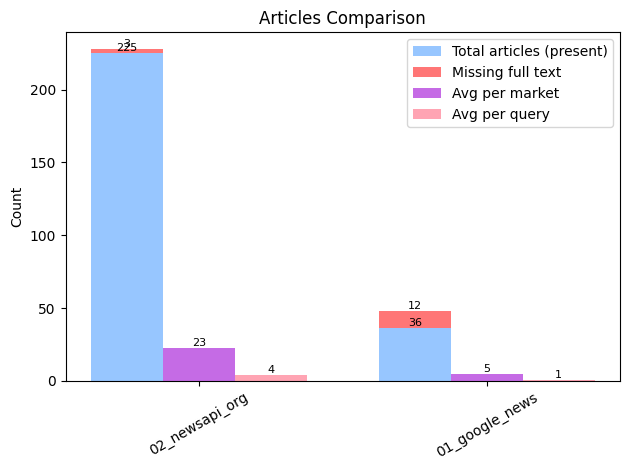

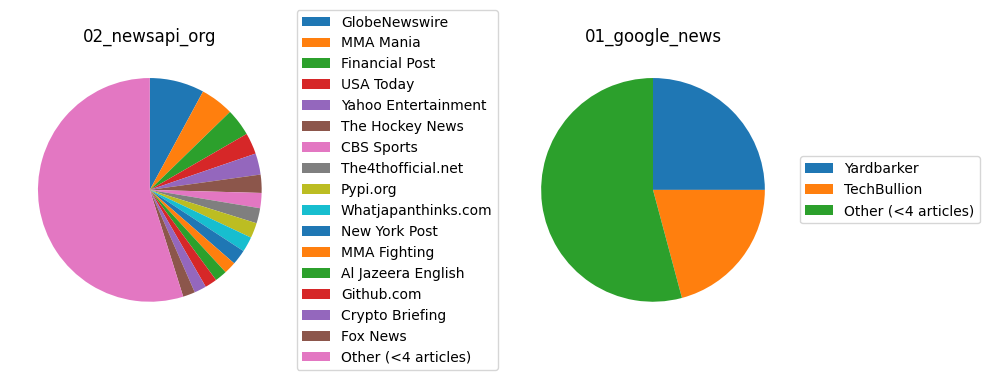

In [50]:
import json
import os
from collections import defaultdict
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np

BASE_DIR = "data"


def load_all_files():
    datasets = {}

    for folder in os.listdir(BASE_DIR):
        if not folder.startswith(tuple([f"{i:02d}_" for i in range(1, 10)])):
            continue

        path = os.path.join(BASE_DIR, folder, "sample_markets_articles_scraped.json")

        if not os.path.exists(path):
            continue

        with open(path, "r", encoding="utf-8") as f:
            datasets[folder] = json.load(f)

    return datasets


def parse_date(d):
    if not d:
        return None
    try:
        return datetime.fromisoformat(d.replace("Z", "+00:00"))
    except Exception:
        return None


def fmt_date(d):
    return d.strftime("%d %B %Y") if d else "N/A"


datasets = load_all_files()

metrics = {}

for name, markets in datasets.items():
    total_articles = 0
    total_queries = 0
    total_markets = len(markets)

    source_counts = defaultdict(int)
    missing_full = 0
    all_dates = []

    for market in markets:
        articles = market.get("articles", [])
        queries = market.get("search_queries", [])

        total_articles += len(articles)
        total_queries += len(queries)

        for a in articles:
            if not a.get("full_text"):
                missing_full += 1

            src = a.get("source") or "Unknown"
            source_counts[src] += 1

            d = parse_date(a.get("published_date"))
            if d:
                all_dates.append(d)

    metrics[name] = {
        "total": total_articles,
        "missing": missing_full,
        "avg_market": total_articles / total_markets if total_markets else 0,
        "avg_query": total_articles / total_queries if total_queries else 0,
        "sources": source_counts,
        "earliest": min(all_dates) if all_dates else None,
        "latest": max(all_dates) if all_dates else None
    }

for name, m in metrics.items():
    print(f"\n===== {name} =====")
    print(f"Earliest article: {fmt_date(m['earliest'])}")
    print(f"Latest article:   {fmt_date(m['latest'])}")

# =========================
# GROUPED BAR PLOT
# =========================

labels = list(metrics.keys())
x = np.arange(len(labels))
width = 0.25

totals = np.array([metrics[k]["total"] for k in labels])
missing = np.array([metrics[k]["missing"] for k in labels])
present = totals - missing
avg_market = np.array([metrics[k]["avg_market"] for k in labels])
avg_query = np.array([metrics[k]["avg_query"] for k in labels])

plt.figure()

# bars
b1 = plt.bar(x - width, present, width, color="#97C6FF", label="Total articles (present)")
b2 = plt.bar(x - width, missing, width, bottom=present, color="#FF7676", label="Missing full text")

b3 = plt.bar(x, avg_market, width, color="#C56BE5", label="Avg per market")
b4 = plt.bar(x + width, avg_query, width, color="#FFA4B3", label="Avg per query")

# add labels on bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height,
                f"{height:.0f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

add_labels(b1)
add_labels(b2)
add_labels(b3)
add_labels(b4)

plt.xticks(x, labels, rotation=30)
plt.title("Articles Comparison")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


# =========================
# PIE CHARTS
# =========================

fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 5))

if len(metrics) == 1:
    axes = [axes]

for ax, (name, m) in zip(axes, metrics.items()):
    sources = dict(m["sources"])

    # split major vs other
    major = {k: v for k, v in sources.items() if v > 3}
    other = sum(v for k, v in sources.items() if v <= 3)

    # sort major by descending count
    major_sorted = dict(sorted(major.items(), key=lambda x: x[1], reverse=True))

    labels = list(major_sorted.keys())
    values = list(major_sorted.values())

    # append "Other" last
    if other > 0:
        labels.append("Other (<4 articles)")
        values.append(other)

    wedges, _ = ax.pie(values, startangle=90, counterclock=False)

    ax.set_title(name)

    ax.legend(
        wedges,
        labels,
        loc="center left",
        bbox_to_anchor=(1, 0.5)
    )

plt.tight_layout()
plt.show()